In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.21.0
GPU available: False


In [13]:
# Final cleaned dataset paths

BASE_PATH = r"D:\Smartvision_project\smartvision_dataset\classification_cleaned"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH = os.path.join(BASE_PATH, "val")
TEST_PATH = os.path.join(BASE_PATH, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\nClasses:")
print(class_names)

print("\nNumber of classes:", num_classes)

Found 1686 files belonging to 25 classes.
Found 343 files belonging to 25 classes.
Found 342 files belonging to 25 classes.

Classes:
['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'truck']

Number of classes: 25


In [14]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

print("✅ Data augmentation created successfully")

✅ Data augmentation created successfully


In [15]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained layers
base_model.trainable = False

print("✅ MobileNetV2 loaded")
print("Total layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

✅ MobileNetV2 loaded
Total layers: 154
Trainable: False


In [16]:
model = tf.keras.Sequential([
    data_augmentation,

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

model.build((None, 224, 224, 3))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,430,297 (9.27 MB)

 Trainable params: 169,753 (663.10 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model compiled successfully")

✅ Model compiled successfully


In [21]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_mobilenetv2_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.2112 - loss: 3.0741 - val_accuracy: 0.1312 - val_loss: 3.4846
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.2378 - loss: 2.9767 - val_accuracy: 0.1545 - val_loss: 3.4697
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.2402 - loss: 2.9407 - val_accuracy: 0.1312 - val_loss: 3.4817
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.2622 - loss: 2.8971 - val_accuracy: 0.1429 - val_loss: 3.4852
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.2711 - loss: 2.7867 - val_accuracy: 0.1429 - val_loss: 3.4696
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.2912 - loss: 2.7891 - val_accuracy: 0.1312 - val_loss: 3.4688
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.3049 - loss: 2.7576 - val_accuracy: 0.1399 - val_loss: 3.4549
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.3203 - loss: 2.6883 - val_accuracy: 0.1224 - val_loss:

In [22]:
# Check the pixel value range coming from the dataset

for images, labels in train_ds.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())
    print("Image shape:", images.shape)

Minimum pixel value: 0.0
Maximum pixel value: 255.0
Image shape: (32, 224, 224, 3)


In [23]:
# MobileNetV2 preprocessing
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

print("✅ MobileNetV2 preprocessing ready")

✅ MobileNetV2 preprocessing ready


In [24]:
model = tf.keras.Sequential([
    data_augmentation,

    tf.keras.layers.Lambda(preprocess_input),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

model.build((None, 224, 224, 3))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,430,297 (9.27 MB)

 Trainable params: 169,753 (663.10 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model compiled successfully")

✅ Model compiled successfully


In [27]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_mobilenetv2_preprocessed.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.0558 - loss: 4.3466 - val_accuracy: 0.0671 - val_loss: 3.4482
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.1115 - loss: 3.7657 - val_accuracy: 0.1166 - val_loss: 3.2164
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.1833 - loss: 3.3537 - val_accuracy: 0.2012 - val_loss: 3.0003
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.2426 - loss: 3.0565 - val_accuracy: 0.2536 - val_loss: 2.8271
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.3286 - loss: 2.7248 - val_accuracy: 0.3236 - val_loss: 2.6954
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.3683 - loss: 2.5967 - val_accuracy: 0.3761 - val_loss: 2.5844
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.4057 - loss: 2.3913 - val_accuracy: 0.4082 - val_loss: 2.5062
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.4259 - loss: 2.3331 - val_accuracy: 0.4227 - val_loss:

In [28]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("=" * 60)
print("📊 FINAL TEST SET RESULTS")
print("=" * 60)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 60)

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 941ms/step - accuracy: 0.3450 - loss: 2.5570
📊 FINAL TEST SET RESULTS
Test Loss     : 2.5570
Test Accuracy : 34.50%


In [29]:
# Unfreeze the last 20 layers of MobileNetV2
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total layers: 154
Trainable layers: 20


In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model recompiled for fine-tuning")
print("Learning rate: 0.00001")

✅ Model recompiled for fine-tuning
Learning rate: 0.00001


In [31]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-7
        )
    ]
)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.4241 - loss: 2.3256 - val_accuracy: 0.4286 - val_loss: 2.3251 - learning_rate: 1.0000e-05
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.4342 - loss: 2.2826 - val_accuracy: 0.4169 - val_loss: 2.2939 - learning_rate: 1.0000e-05
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.4526 - loss: 2.1820 - val_accuracy: 0.4257 - val_loss: 2.2779 - learning_rate: 1.0000e-05
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.4609 - loss: 2.1753 - val_accuracy: 0.4198 - val_loss: 2.2622 - learning_rate: 1.0000e-05
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.4852 - loss: 2.0624 - val_accuracy: 0.4227 - val_loss: 2.2523 - learning_rate: 1.0000e-05


In [32]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("=" * 60)
print("📊 MODEL 4 — FINE-TUNED TEST RESULTS")
print("=" * 60)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 60)

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 904ms/step - accuracy: 0.3392 - loss: 2.4753
📊 MODEL 4 — FINE-TUNED TEST RESULTS
Test Loss     : 2.4753
Test Accuracy : 33.92%


In [33]:
# ============================================================
# MODEL 5 — EFFICIENTNETB0
# ============================================================

base_model_5 = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model_5.trainable = False

print("✅ EfficientNetB0 loaded")
print("Total layers:", len(base_model_5.layers))
print("Trainable:", base_model_5.trainable)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
✅ EfficientNetB0 loaded
Total layers: 238
Trainable: False


In [34]:
# ============================================================
# BUILD MODEL 5 — EFFICIENTNETB0
# ============================================================

model_5 = tf.keras.Sequential([
    base_model_5,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        25,
        activation="softmax"
    )
])

model_5.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,221,884 (16.11 MB)

 Trainable params: 169,753 (663.10 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [35]:
model_5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model 5 compiled")

✅ Model 5 compiled


In [38]:
# ============================================================
# MODEL 5 — EFFICIENTNETB0 TRAINING
# ============================================================

callbacks_5 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history_5 = model_5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_5
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8903 - loss: 0.6320 - val_accuracy: 0.4257 - val_loss: 2.1262 - learning_rate: 2.5000e-04
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8998 - loss: 0.6023 - val_accuracy: 0.4257 - val_loss: 2.1561 - learning_rate: 2.5000e-04
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9122 - loss: 0.5683 - val_accuracy: 0.4461 - val_loss: 2.1785 - learning_rate: 2.5000e-04
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9176 - loss: 0.5364 - val_accuracy: 0.4461 - val_loss: 2.1964 - learning_rate: 1.2500e-04


In [39]:
test_loss_5, test_accuracy_5 = model_5.evaluate(test_ds)

print("=" * 60)
print("📊 MODEL 5 — EFFICIENTNETB0 TEST RESULTS")
print("=" * 60)
print(f"Test Loss     : {test_loss_5:.4f}")
print(f"Test Accuracy : {test_accuracy_5 * 100:.2f}%")
print("=" * 60)

11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4474 - loss: 2.2154
📊 MODEL 5 — EFFICIENTNETB0 TEST RESULTS
Test Loss     : 2.2154
Test Accuracy : 44.74%


In [40]:
model_5.save("efficientnetb0_baseline.keras")

print("✅ EfficientNetB0 baseline saved")

✅ EfficientNetB0 baseline saved


In [41]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

y_prob = model_5.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

print("Predictions generated:", len(y_pred))
print("True labels:", len(y_true))

11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step
Predictions generated: 342
True labels: 342


In [42]:
print("=" * 70)
print("📊 EFFICIENTNETB0 — CLASSIFICATION REPORT")
print("=" * 70)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3
)

print(report)

📊 EFFICIENTNETB0 — CLASSIFICATION REPORT
               precision    recall  f1-score   support

     airplane      0.765     0.867     0.812        15
          bed      0.647     0.733     0.688        15
        bench      0.097     0.250     0.140        12
      bicycle      0.833     0.769     0.800        13
         bird      1.000     0.286     0.444        14
       bottle      0.923     0.800     0.857        15
         bowl      0.286     0.364     0.320        11
          bus      0.714     0.333     0.455        15
         cake      0.129     0.267     0.174        15
          car      0.000     0.000     0.000         5
          cat      0.722     0.867     0.788        15
        chair      0.000     0.000     0.000        14
        couch      0.556     0.357     0.435        14
          cow      1.000     0.600     0.750        15
          cup      0.000     0.000     0.000        12
          dog      0.500     0.267     0.348        15
     elephant      1.00

In [43]:
print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [44]:
# Check one training batch
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Pixel minimum:", tf.reduce_min(images).numpy())
print("Pixel maximum:", tf.reduce_max(images).numpy())
print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Pixel minimum: 0.0
Pixel maximum: 255.0
Label batch shape: (32,)


In [45]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

print("✅ Data augmentation created")

✅ Data augmentation created


In [46]:
# ============================================================
# MODEL 6 — EFFICIENTNETB0 + DATA AUGMENTATION
# ============================================================

base_model_6 = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model_6.trainable = False

model_6 = tf.keras.Sequential([
    data_augmentation,

    base_model_6,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        25,
        activation="softmax"
    )
])

model_6.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_5           │ ?                           │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [47]:
model_6.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model 6 compiled")

✅ Model 6 compiled


In [48]:
callbacks_6 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history_6 = model_6.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_6
)

Epoch 1/10


C:\Users\admin\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


53/53 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.1779 - loss: 3.5382 - val_accuracy: 0.3178 - val_loss: 2.9296 - learning_rate: 5.0000e-04
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.4632 - loss: 2.1855 - val_accuracy: 0.4431 - val_loss: 2.5990 - learning_rate: 5.0000e-04
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.5635 - loss: 1.7747 - val_accuracy: 0.4140 - val_loss: 2.3712 - learning_rate: 5.0000e-04
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.6364 - loss: 1.5716 - val_accuracy: 0.4169 - val_loss: 2.2435 - learning_rate: 5.0000e-04
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.6726 - loss: 1.3606 - val_accuracy: 0.4198 - val_loss: 2.1763 - learning_rate: 5.0000e-04
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.7082 - loss: 1.2287 - val_accuracy: 0.4694 - val_loss: 2.1544 - learning_rate: 5.0000e-04
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.7153 - loss: 1.185

In [49]:
test_loss_6, test_accuracy_6 = model_6.evaluate(test_ds)

print("=" * 60)
print("📊 MODEL 6 — EFFICIENTNETB0 + AUGMENTATION")
print("============================================================")
print(f"Test Loss     : {test_loss_6:.4f}")
print(f"Test Accuracy : {test_accuracy_6 * 100:.2f}%")
print("=" * 60)

11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4474 - loss: 2.2993
📊 MODEL 6 — EFFICIENTNETB0 + AUGMENTATION
Test Loss     : 2.2993
Test Accuracy : 44.74%


In [50]:
# ============================================================
# MODEL 7 — EFFICIENTNETB0 FINE-TUNING
# ============================================================

base_model_7 = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Unfreeze only the last 20 layers
base_model_7.trainable = True

for layer in base_model_7.layers[:-20]:
    layer.trainable = False

print("✅ EfficientNetB0 loaded for fine-tuning")
print("Total layers:", len(base_model_7.layers))
print(
    "Trainable layers:",
    sum(layer.trainable for layer in base_model_7.layers)
)

✅ EfficientNetB0 loaded for fine-tuning
Total layers: 238
Trainable layers: 20


In [51]:
# ============================================================
# BUILD MODEL 7 — EFFICIENTNETB0 FINE-TUNING
# ============================================================

model_7 = tf.keras.Sequential([
    base_model_7,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        25,
        activation="softmax"
    )
])

model_7.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_6           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,221,884 (16.11 MB)

 Trainable params: 1,520,713 (5.80 MB)

 Non-trainable params: 2,701,171 (10.30 MB)

In [52]:
model_7.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model 7 compiled for fine-tuning")
print("Learning rate: 0.00001")

✅ Model 7 compiled for fine-tuning
Learning rate: 0.00001


In [53]:
# ============================================================
# MODEL 7 — EFFICIENTNETB0 FINE-TUNING
# ============================================================

callbacks_7 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-7
    )
]

history_7 = model_7.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks_7
)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.0403 - loss: 4.5589 - val_accuracy: 0.0321 - val_loss: 3.5630 - learning_rate: 1.0000e-05
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.0593 - loss: 4.3173 - val_accuracy: 0.0350 - val_loss: 3.5531 - learning_rate: 1.0000e-05
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.0605 - loss: 4.1720 - val_accuracy: 0.0554 - val_loss: 3.5442 - learning_rate: 1.0000e-05
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.0949 - loss: 3.9376 - val_accuracy: 0.0758 - val_loss: 3.5321 - learning_rate: 1.0000e-05
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.1210 - loss: 3.7170 - val_accuracy: 0.0962 - val_loss: 3.5106 - learning_rate: 1.0000e-05


In [54]:
# ============================================================
# MODEL 8 — CORRECT FINE-TUNING FROM TRAINED MODEL 5
# ============================================================

model_8 = tf.keras.models.load_model(
    r"D:\Smartvision_project\efficientnetb0_baseline.keras"
)

print("✅ Model 5 loaded successfully")

✅ Model 5 loaded successfully


In [55]:
# ============================================================
# UNFREEZE LAST 20 EFFICIENTNETB0 LAYERS
# ============================================================

base_model_8 = model_8.layers[0]

base_model_8.trainable = True

for layer in base_model_8.layers[:-20]:
    layer.trainable = False

print("✅ Model 8 prepared for fine-tuning")
print("Total EfficientNetB0 layers:", len(base_model_8.layers))
print(
    "Trainable EfficientNetB0 layers:",
    sum(layer.trainable for layer in base_model_8.layers)
)

✅ Model 8 prepared for fine-tuning
Total EfficientNetB0 layers: 238
Trainable EfficientNetB0 layers: 20


In [56]:
# ============================================================
# COMPILE MODEL 8 FOR FINE-TUNING
# ============================================================

model_8.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model 8 compiled for fine-tuning")
print("Learning rate: 0.00001")

✅ Model 8 compiled for fine-tuning
Learning rate: 0.00001


In [62]:
test_loss_8, test_accuracy_8 = model_8.evaluate(test_ds)

print("=" * 60)
print("📊 MODEL 8 — CORRECT FINE-TUNED EFFICIENTNETB0")
print("=" * 60)
print(f"Test Loss     : {test_loss_8:.4f}")
print(f"Test Accuracy : {test_accuracy_8 * 100:.2f}%")
print("=" * 60)

11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4327 - loss: 2.3754
📊 MODEL 8 — CORRECT FINE-TUNED EFFICIENTNETB0
Test Loss     : 2.3754
Test Accuracy : 43.27%


In [66]:
# ============================================================
# PHASE 2.5 — SAVE FINAL CLASSIFICATION MODEL
# ============================================================

final_model_path = r"D:\Smartvision_project\efficientnetb0_final.keras"

model_5.save(final_model_path)

print("=" * 60)
print("✅ FINAL CLASSIFICATION MODEL SAVED")
print("=" * 60)
print("Model: EfficientNetB0")
print("Test Accuracy: 44.74%")
print("Saved to:", final_model_path)
print("=" * 60)

✅ FINAL CLASSIFICATION MODEL SAVED
Model: EfficientNetB0
Test Accuracy: 44.74%
Saved to: D:\Smartvision_project\efficientnetb0_final.keras


In [67]:
# ============================================================
# PHASE 2.5.2 — FINAL CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report
import numpy as np

# Generate predictions using FINAL MODEL
y_pred_prob = model_5.predict(test_ds, verbose=1)

y_pred = np.argmax(y_pred_prob, axis=1)

# Get true labels
y_true = np.concatenate([y.numpy() for _, y in test_ds])

print("=" * 70)
print("📊 FINAL EFFICIENTNETB0 CLASSIFICATION REPORT")
print("=" * 70)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3
)

print(report)

11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step
📊 FINAL EFFICIENTNETB0 CLASSIFICATION REPORT
               precision    recall  f1-score   support

     airplane      0.765     0.867     0.812        15
          bed      0.647     0.733     0.688        15
        bench      0.097     0.250     0.140        12
      bicycle      0.833     0.769     0.800        13
         bird      1.000     0.286     0.444        14
       bottle      0.923     0.800     0.857        15
         bowl      0.286     0.364     0.320        11
          bus      0.714     0.333     0.455        15
         cake      0.129     0.267     0.174        15
          car      0.000     0.000     0.000         5
          cat      0.722     0.867     0.788        15
        chair      0.000     0.000     0.000        14
        couch      0.556     0.357     0.435        14
          cow      1.000     0.600     0.750        15
          cup      0.000     0.000     0.000        12
          dog      0.500     0.267 

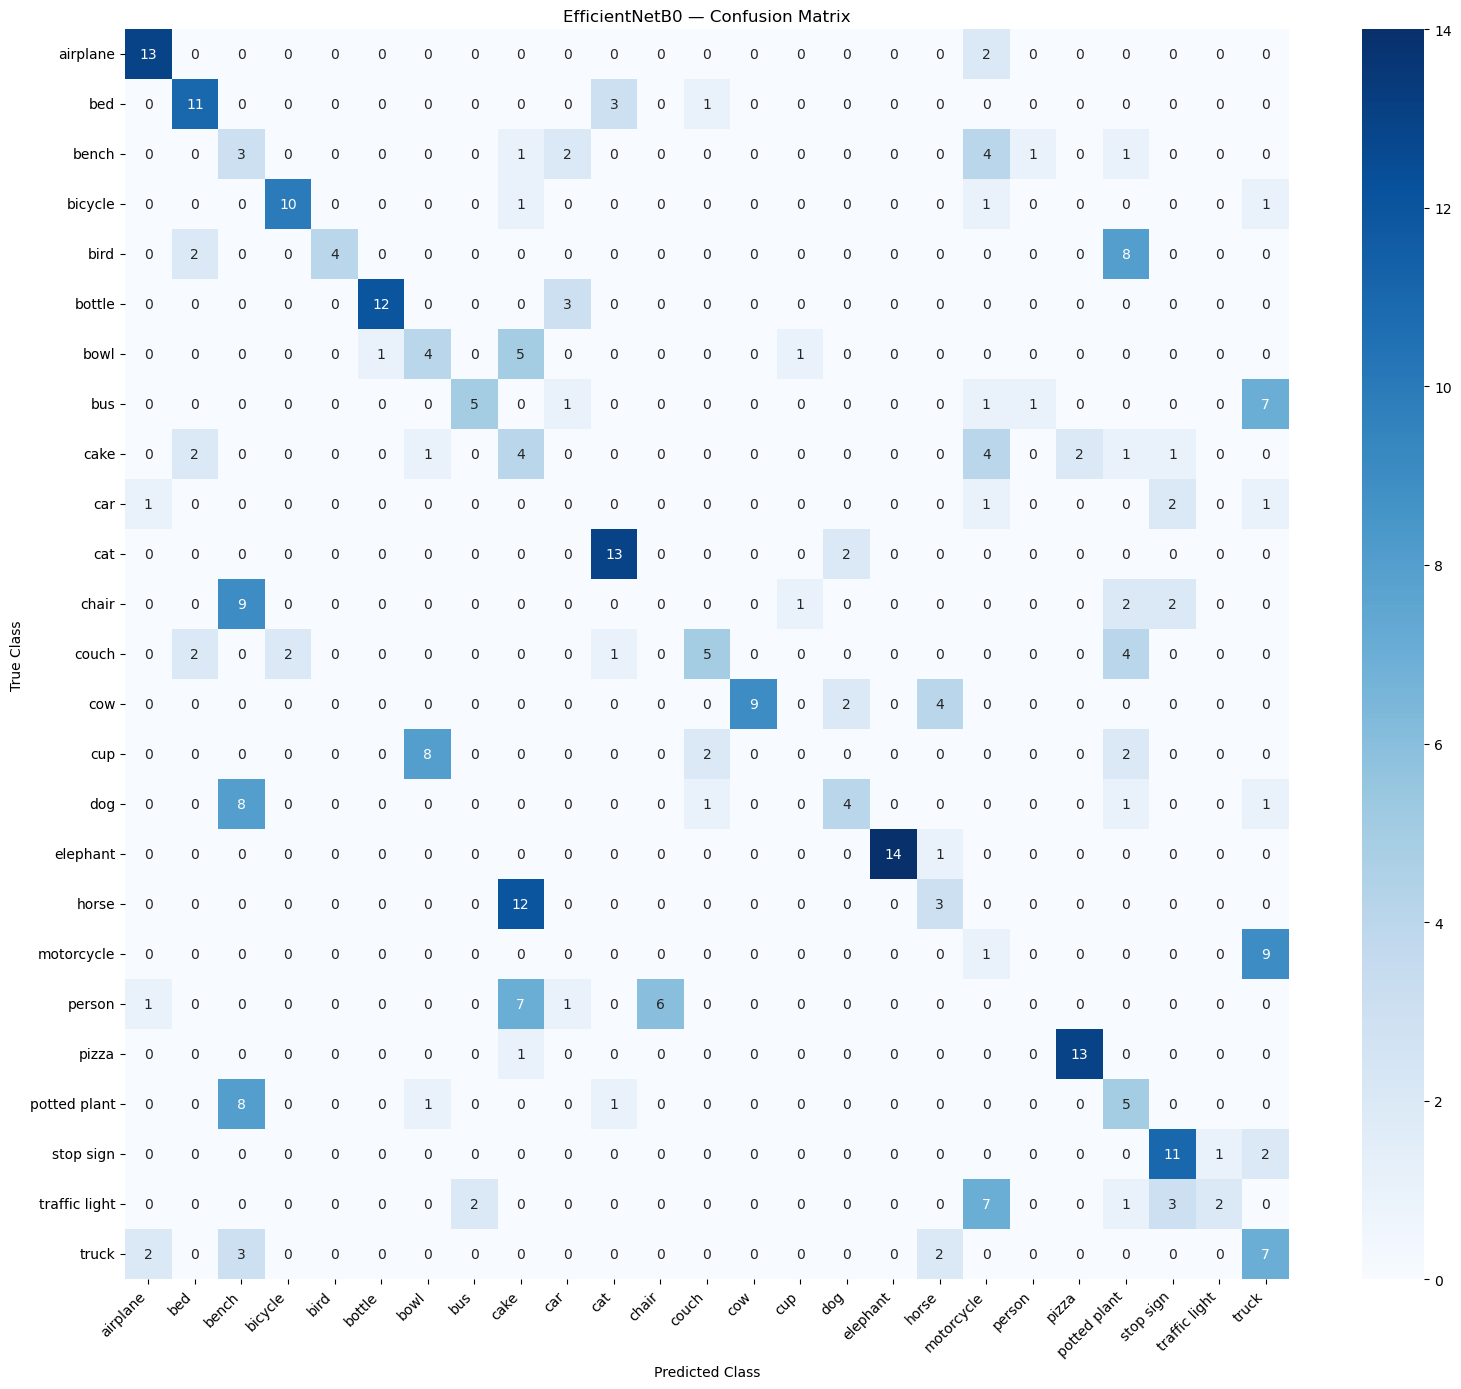

In [68]:
# ============================================================
# PHASE 2.5.3 — CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("EfficientNetB0 — Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [69]:
# ============================================================
# PHASE 2.5.4 — TOP-5 ACCURACY
# ============================================================

import numpy as np

# Get top-5 predicted class indices
top5_predictions = np.argsort(y_pred_prob, axis=1)[:, -5:]

# Check whether true class is among top 5
top5_correct = np.array([
    true_label in predicted_labels
    for true_label, predicted_labels in zip(y_true, top5_predictions)
])

top5_accuracy = top5_correct.mean()

print("=" * 60)
print("📊 EFFICIENTNETB0 — TOP-5 ACCURACY")
print("=" * 60)
print(f"Top-1 Accuracy : {(y_pred == y_true).mean() * 100:.2f}%")
print(f"Top-5 Accuracy : {top5_accuracy * 100:.2f}%")
print("=" * 60)

📊 EFFICIENTNETB0 — TOP-5 ACCURACY
Top-1 Accuracy : 44.74%
Top-5 Accuracy : 77.78%


In [70]:
# ============================================================
# PHASE 2.5.5 — FINAL MODEL COMPARISON
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "MobileNetV2",
        "MobileNetV2 Fine-Tuned",
        "EfficientNetB0",
        "EfficientNetB0 + Augmentation",
        "EfficientNetB0 Fine-Tuned"
    ],
    "Test Accuracy (%)": [
        34.50,
        33.92,
        44.74,
        44.74,
        43.27
    ]
})

print("=" * 70)
print("📊 FINAL CNN MODEL COMPARISON")
print("=" * 70)

display(comparison)

print("\n🏆 BEST MODEL:")
print("EfficientNetB0")
print("Test Accuracy: 44.74%")
print("Top-5 Accuracy: 77.78%")

📊 FINAL CNN MODEL COMPARISON


,Model,Test Accuracy (%)
0,MobileNetV2,34.50
1,MobileNetV2 Fine-Tuned,33.92
2,EfficientNetB0,44.74
3,EfficientNetB0 + Augmentation,44.74
4,EfficientNetB0 Fine-Tuned,43.27



🏆 BEST MODEL:
EfficientNetB0
Test Accuracy: 44.74%
Top-5 Accuracy: 77.78%


In [71]:
# ============================================================
# PHASE 2.6 — VGG16 TRANSFER LEARNING
# ============================================================

import tensorflow as tf
from tensorflow.keras.applications import VGG16

vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

vgg_base.trainable = False

print("✅ VGG16 loaded")
print("Total layers:", len(vgg_base.layers))
print("Trainable:", vgg_base.trainable)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 41s 1us/step
✅ VGG16 loaded
Total layers: 19
Trainable: False


In [72]:
# ============================================================
# VGG16 CLASSIFICATION MODEL
# ============================================================

from tensorflow.keras import layers, models

vgg_model = models.Sequential([
    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(25, activation="softmax")
])

vgg_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_7           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,785,625 (56.40 MB)

 Trainable params: 69,913 (273.10 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [73]:
# ============================================================
# VGG16 — COMPILE
# ============================================================

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ VGG16 compiled")
print("Learning rate: 0.0005")

✅ VGG16 compiled
Learning rate: 0.0005


In [74]:
# ============================================================
# VGG16 — TRAINING
# ============================================================

vgg_history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


C:\Users\admin\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


53/53 ━━━━━━━━━━━━━━━━━━━━ 701s 13s/step - accuracy: 0.1079 - loss: 3.5667 - val_accuracy: 0.1808 - val_loss: 3.0042
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 734s 14s/step - accuracy: 0.3019 - loss: 2.4896 - val_accuracy: 0.2507 - val_loss: 2.5371
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 606s 10s/step - accuracy: 0.4425 - loss: 2.0161 - val_accuracy: 0.3294 - val_loss: 2.3280
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 566s 11s/step - accuracy: 0.5308 - loss: 1.7167 - val_accuracy: 0.3644 - val_loss: 2.2386
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 612s 12s/step - accuracy: 0.5682 - loss: 1.5238 - val_accuracy: 0.3965 - val_loss: 2.1348


In [75]:
# ============================================================
# VGG16 — FINAL TEST EVALUATION
# ============================================================

vgg_test_loss, vgg_test_accuracy = vgg_model.evaluate(
    test_ds,
    verbose=1
)

print("=" * 60)
print("📊 VGG16 — TEST RESULTS")
print("=" * 60)
print(f"Test Loss     : {vgg_test_loss:.4f}")
print(f"Test Accuracy : {vgg_test_accuracy * 100:.2f}%")
print("=" * 60)

11/11 ━━━━━━━━━━━━━━━━━━━━ 93s 8s/step - accuracy: 0.3538 - loss: 2.3805
📊 VGG16 — TEST RESULTS
Test Loss     : 2.3805
Test Accuracy : 35.38%
